In [1]:
%%capture

import os
from pathlib import Path

project_root = "."
i=0
try:
    os.chdirdir(project_root)
    assert Path('.gitignore').is_file()
except:
    while i<4 and (not Path('.gitignore').is_file()):
        os.chdir(Path(Path.cwd(), '../'))
        i+=1
    project_root = Path.cwd()
print(Path.cwd())

In [2]:
import pandas as pd
import numpy as np
# from scipy.signal import argrelextrema
# from sklearn.linear_model import LinearRegression
# from datetime import datetime, date, timedelta, timezone, time
import talib.abstract as ta
# import seaborn as sns
import matplotlib.pyplot as plt
import freqtrade.vendor.qtpylib.indicators as qtpylib
from freqtrade.strategy import merge_informative_pair
from freqtrade.data.btanalysis import load_backtest_data, load_trades_from_db
import json
from user_data.strategies.atlas_engine import AtlasEngine
from freqtrade.configuration import Configuration

In [3]:
%%capture
ticker = "ETH"
config = Configuration.from_files(["user_data/config.json"])
backtest_dir = config["user_data_dir"] / "backtest_results"
base_url = "/home/mo/Repositories/trade/user_data/data/bybit/futures/"
strategy = AtlasEngine(config)

In [ ]:
trades = load_trades_from_db("sqlite:///user_data/atlas_engine.sqlite")

In [15]:
%%capture
trades = load_backtest_data(backtest_dir)
trades['color'] = np.where(trades.profit_abs >= 0, 'green', 'red')

In [5]:
with open('user_data/strategies/atlas_engine.json', mode="r") as file:
    conf = json.load(file)
values = conf.get('params').get('buy')

In [13]:
def analyze_strategy():
    timeframe = strategy.timeframe
    inf_tf = strategy.inf_tf
    dataframe = pd.read_feather(f"{base_url}{ticker}_USDT_USDT-{timeframe}-futures.feather")
    inf_dataframe = pd.read_feather(f"{base_url}{ticker}_USDT_USDT-{inf_tf}-futures.feather")

    strategy.populate_indicators_(inf_dataframe, metadata={})
    dataframe = merge_informative_pair(dataframe, inf_dataframe, timeframe, inf_tf)
    dataframe = strategy.populate_indicators(dataframe, metadata={})

    dataframe = strategy.populate_entry_trend(dataframe, metadata={})
    dataframe = strategy.populate_exit_trend(dataframe, metadata={})

    return dataframe

In [14]:
dataframe = analyze_strategy()

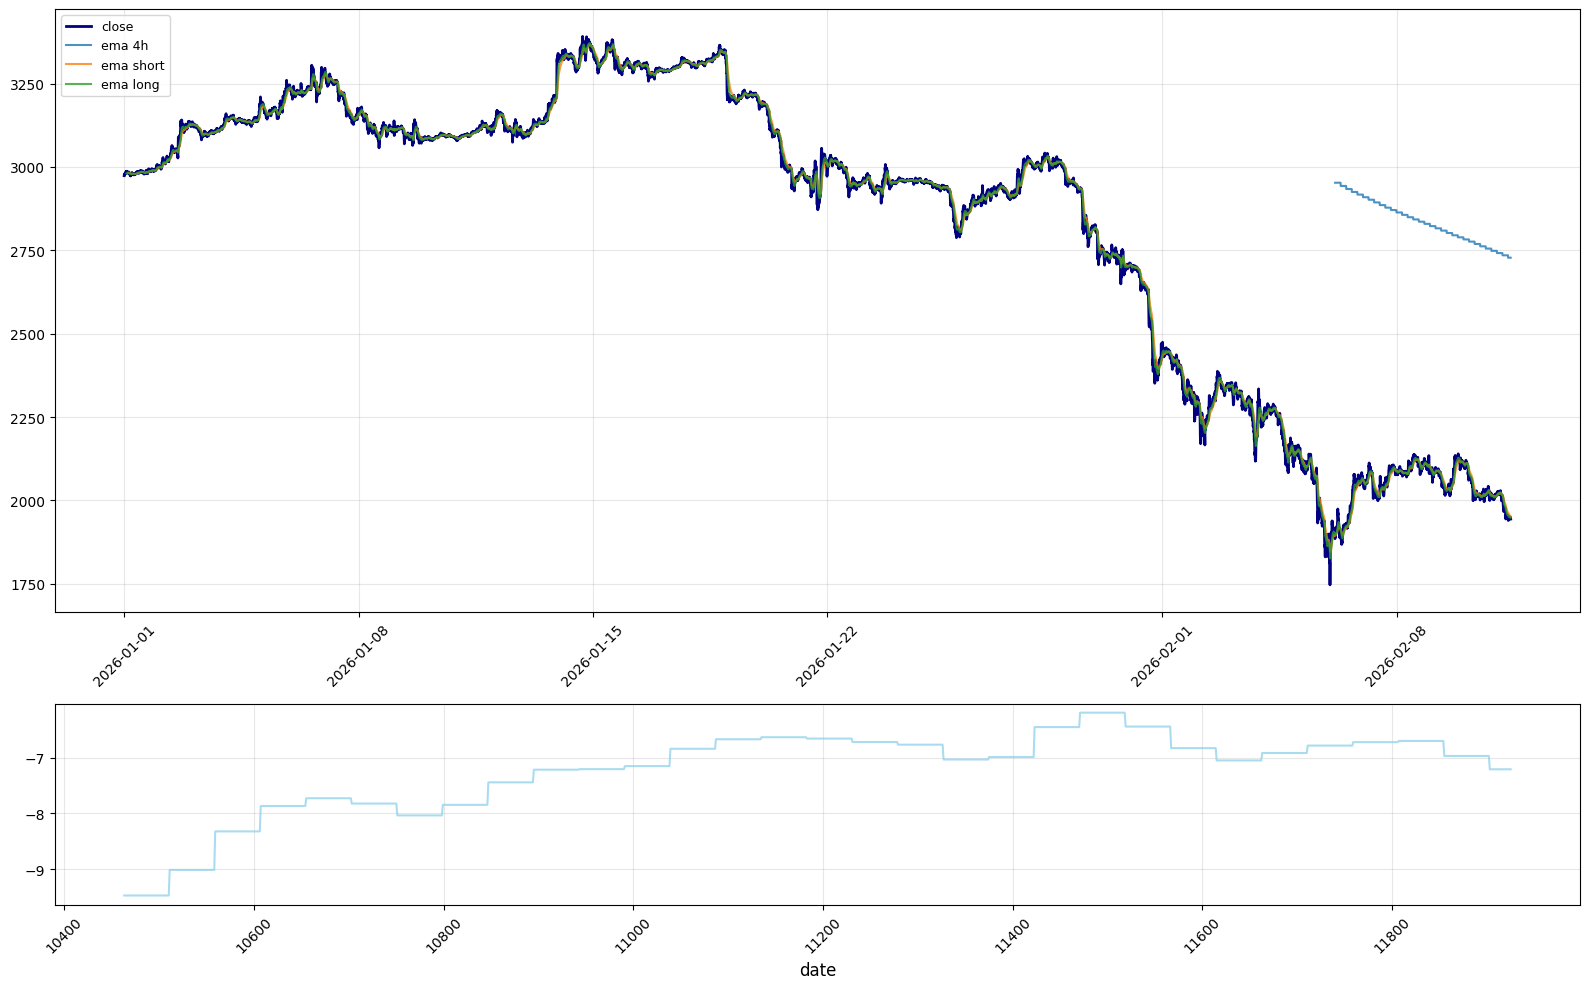

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(dataframe.date, dataframe['close'], label='close', color='navy', linewidth=2)
ax1.plot(dataframe.date, dataframe[f'ema_4h'], linewidth=1.5, alpha=0.8,label='ema 4h')
ax1.plot(dataframe.date, dataframe[f'ema_short'], linewidth=1.5, alpha=0.8, label='ema short')
ax1.plot(dataframe.date, dataframe[f'ema_long'], linewidth=1.5, alpha=0.8, label='ema long')

ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(dataframe.index, dataframe['ema_first_derivative_4h'], color='skyblue', alpha=0.7)
ax2.set_xlabel('date', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)


plt.tight_layout()
plt.show()

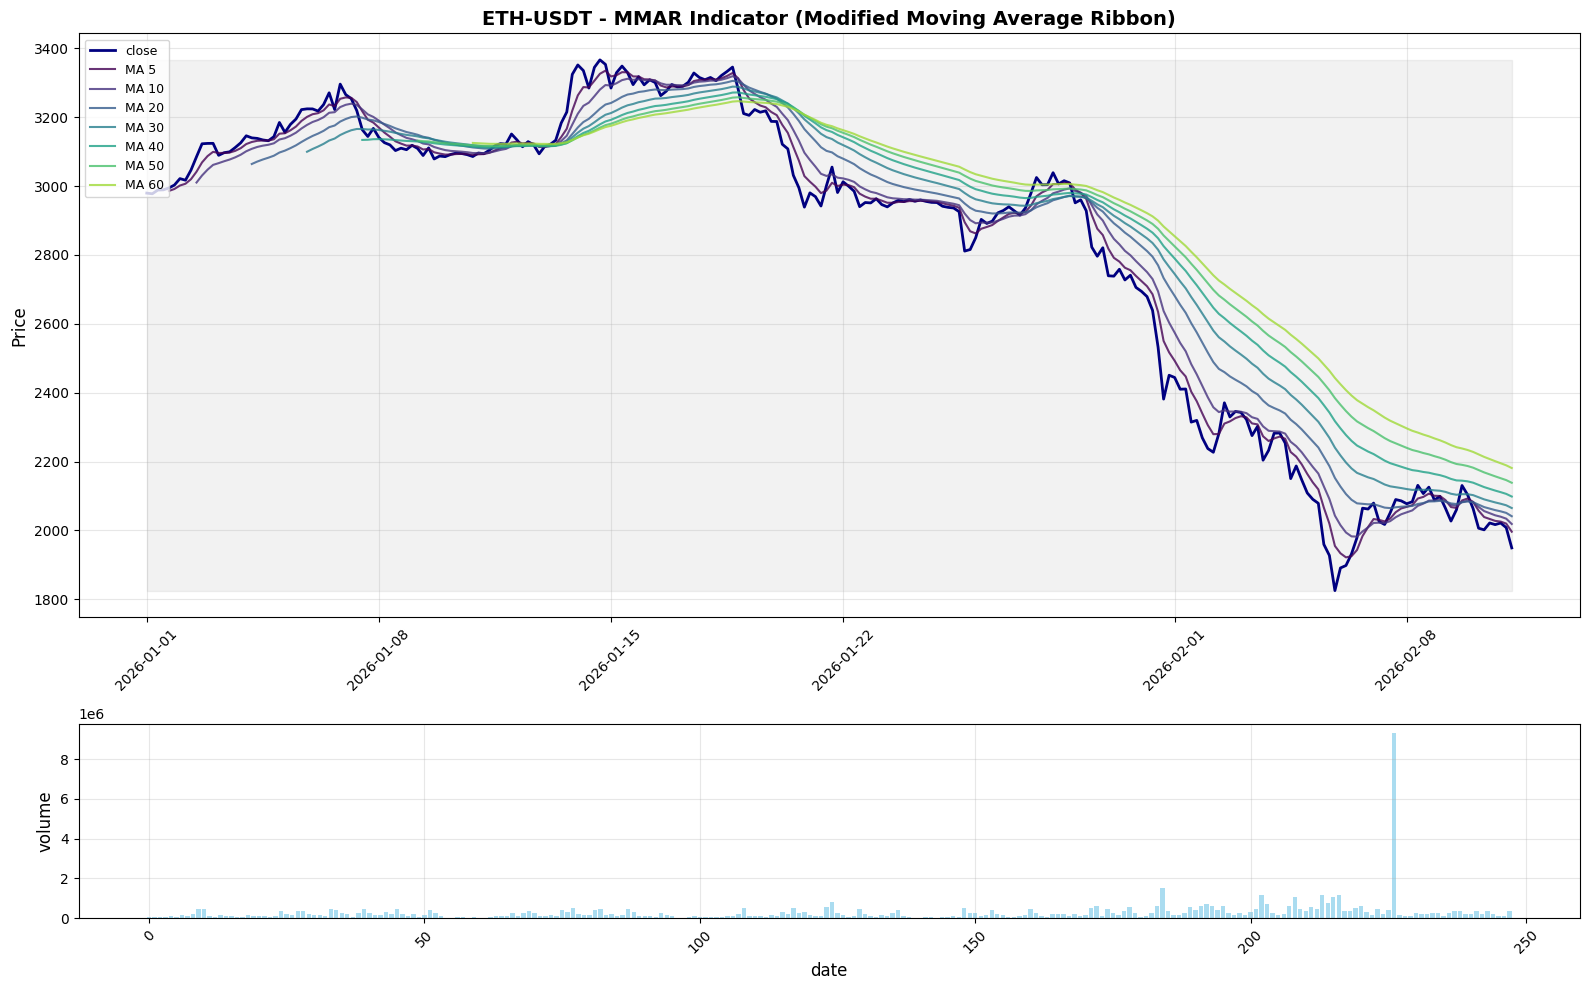


📊 اطلاعات MMAR:
میانگین متحرک 5 دوره‌ای: 1996.43
میانگین متحرک 10 دوره‌ای: 2018.80
میانگین متحرک 20 دوره‌ای: 2041.36
میانگین متحرک 30 دوره‌ای: 2065.14
میانگین متحرک 40 دوره‌ای: 2098.55
میانگین متحرک 50 دوره‌ای: 2138.49
میانگین متحرک 60 دوره‌ای: 2181.26


In [16]:
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import numpy as np

# دریافت داده
symbol = "ETH-USDT"  # یا هر نماد دیگر
df = dataframe_4h.copy()

# محاسبه MMAR با تابع اختصاصی
# اگر تابع mmar مستقیم وجود نداشت، می‌توانیم از روش زیر استفاده کنیم:
lengths = [5, 10, 20, 30, 40, 50, 60]
mamode = 'ema'

# ایجاد ستون‌های MMAR
for length in lengths:
    df[f'MA_{length}'] = ta.ema(df['close'], length=length)

# رسم نمودار با جزئیات بیشتر
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), 
                                gridspec_kw={'height_ratios': [3, 1]})

# نمودار قیمت و MMAR
ax1.plot(df.date, df['close'], label='close', color='navy', linewidth=2)

# رسم هر خط MMAR با رنگ متفاوت
colormap = plt.cm.viridis
for idx, length in enumerate(lengths):
    color = colormap(idx / len(lengths))
    ax1.plot(df.date, df[f'MA_{length}'], 
             label=f'MA {length}',
             color=color,
             linewidth=1.5,
             alpha=0.8)

ax1.set_title(f'{symbol} - MMAR Indicator (Modified Moving Average Ribbon)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Price', fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.fill_between(df.date, df['close'].min(), df['close'].max(), 
                  alpha=0.1, color='gray')

# نمودار حجم معاملات
ax2.bar(df.index, df['volume'], color='skyblue', alpha=0.7)
ax2.set_ylabel('volume', fontsize=12)
ax2.set_xlabel('date', fontsize=12)
ax2.grid(True, alpha=0.3)

# چرخش برچسب تاریخ
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)


plt.tight_layout()
plt.show()

# نمایش اطلاعات آماری
print("\n📊 اطلاعات MMAR:")
for length in lengths:
    last_value = df[f'MA_{length}'].iloc[-1]
    print(f'میانگین متحرک {length} دوره‌ای: {last_value:.2f}')

In [7]:
dataframe = dataframe_1d.copy()

In [17]:
dataframe['sma'] = ta.SMA(dataframe['close'], timeperiod=20)
dataframe['gradient'] = dataframe['sma'].diff()
dataframe['sma_gradient'] = ta.SMA(dataframe['gradient'], timeperiod=20)
dataframe

,date,open,high,low,close,volume,sma,gradient,sma_gradient
0,2023-12-18 00:00:00+00:00,41395.2,42810.6,40566.0,42683.6,163735.590,NaN,NaN,NaN
1,2023-12-19 00:00:00+00:00,42683.6,43548.0,41836.4,42298.0,141858.496,NaN,NaN,NaN
2,2023-12-20 00:00:00+00:00,42298.0,44355.0,42206.3,43710.0,169804.361,NaN,NaN,NaN
3,2023-12-21 00:00:00+00:00,43710.0,44290.0,43324.3,43902.1,116069.192,NaN,NaN,NaN
4,2023-12-22 00:00:00+00:00,43902.1,44473.9,43414.1,44010.0,103438.936,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
744,2025-12-31 00:00:00+00:00,88458.0,89194.3,87177.8,87594.9,45406.525,87830.355,-244.440,-108.69225
745,2026-01-01 00:00:00+00:00,87594.9,88891.9,87515.0,88810.1,24082.533,87759.315,-71.040,-126.06775
746,2026-01-02 00:00:00+00:00,88810.1,90958.5,88325.9,89953.8,80011.551,87747.685,-11.630,-135.10825
747,2026-01-03 00:00:00+00:00,89953.8,90706.4,89255.1,90599.9,25358.895,87871.880,124.195,-128.58825


In [9]:
import matplotlib.pyplot as plt

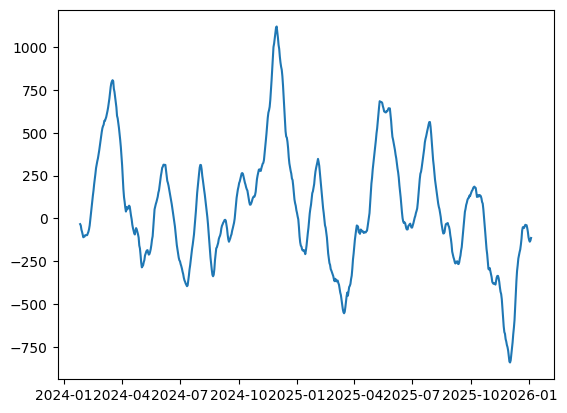

In [18]:
plt.plot(dataframe.date, dataframe.sma_gradient)
plt.show()

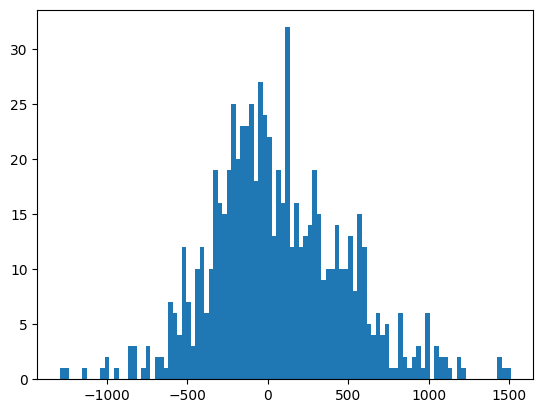

In [20]:
plt.hist(dataframe['gradient'], bins=100)
plt.show()

In [24]:
dataframe[dataframe.gradient > 0].gradient.mean()

np.float64(373.6452000000003)

In [25]:
dataframe[dataframe.gradient < 0].gradient.mean()

np.float64(-269.2610310734466)

In [26]:
dataframe.gradient.abs().mean()

np.float64(322.9565912208508)

In [ ]:
from user_data.utils.custom_indicators import CustomIndicators

In [ ]:
ci = CustomIndicators